## 0. Config

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython import display
import copy
import nltk
from collections import Counter
import gensim.downloader as api

In [2]:
random_state = 123
torch.manual_seed(random_state)
np.random.seed(random_state)

## 1. Data preparing

In [3]:
df = pd.read_csv("Train_rev1.csv")
print(len(df))
df.head()

244768


,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


In [4]:
cat_features = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
text_features = ["FullDescription"]
df_final = df[cat_features + text_features + ["SalaryNormalized"]].copy()
df_final.head()

,Category,Company,LocationNormalized,ContractType,ContractTime,FullDescription,SalaryNormalized
0,Engineering Jobs,Gregory Martin International,Dorking,NaN,permanent,Engineering Systems Analyst Dorking Surrey Sal...,25000
1,Engineering Jobs,Gregory Martin International,Glasgow,NaN,permanent,Stress Engineer Glasgow Salary **** to **** We...,30000
2,Engineering Jobs,Gregory Martin International,Hampshire,NaN,permanent,Mathematical Modeller / Simulation Analyst / O...,30000
3,Engineering Jobs,Gregory Martin International,Surrey,NaN,permanent,Engineering Systems Analyst / Mathematical Mod...,27500
4,Engineering Jobs,Gregory Martin International,Surrey,NaN,permanent,"Pioneer, Miser Engineering Systems Analyst Do...",25000


In [5]:
# missing values
print(df_final.isna().sum())
for column in cat_features:
    df_final[column] = df_final[column].fillna("Missing").astype(str)
df_final.head()

Category                   0
Company                32430
LocationNormalized         0
ContractType          179326
ContractTime           63905
FullDescription            0
SalaryNormalized           0
dtype: int64


,Category,Company,LocationNormalized,ContractType,ContractTime,FullDescription,SalaryNormalized
0,Engineering Jobs,Gregory Martin International,Dorking,Missing,permanent,Engineering Systems Analyst Dorking Surrey Sal...,25000
1,Engineering Jobs,Gregory Martin International,Glasgow,Missing,permanent,Stress Engineer Glasgow Salary **** to **** We...,30000
2,Engineering Jobs,Gregory Martin International,Hampshire,Missing,permanent,Mathematical Modeller / Simulation Analyst / O...,30000
3,Engineering Jobs,Gregory Martin International,Surrey,Missing,permanent,Engineering Systems Analyst / Mathematical Mod...,27500
4,Engineering Jobs,Gregory Martin International,Surrey,Missing,permanent,"Pioneer, Miser Engineering Systems Analyst Do...",25000


In [6]:
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col])
    label_encoders[col] = le
df_final[cat_features] = df_final[cat_features]+1
df_final.head()

,Category,Company,LocationNormalized,ContractType,ContractTime,FullDescription,SalaryNormalized
0,9,7758,751,1,3,Engineering Systems Analyst Dorking Surrey Sal...,25000
1,9,7758,987,1,3,Stress Engineer Glasgow Salary **** to **** We...,30000
2,9,7758,1069,1,3,Mathematical Modeller / Simulation Analyst / O...,30000
3,9,7758,2310,1,3,Engineering Systems Analyst / Mathematical Mod...,27500
4,9,7758,2310,1,3,"Pioneer, Miser Engineering Systems Analyst Do...",25000


(array([8.18240e+04, 1.06594e+05, 3.91120e+04, 1.18100e+04, 5.13200e+03,
        9.60000e+01, 9.70000e+01, 5.60000e+01, 2.80000e+01, 1.90000e+01]),
 array([  5000.,  24500.,  44000.,  63500.,  83000., 102500., 122000.,
        141500., 161000., 180500., 200000.]),
 <BarContainer object of 10 artists>)

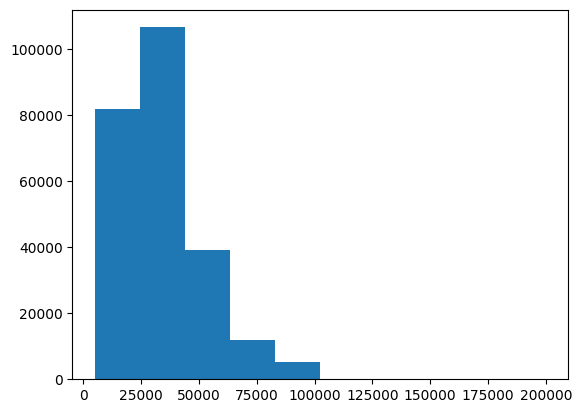

In [7]:
plt.hist(df_final.SalaryNormalized)

In [8]:
# 80% train, 10% valid, 10% test
x_temp, x_test, y_temp, y_test = train_test_split(df_final.drop("SalaryNormalized", axis=1), np.log1p(df_final.SalaryNormalized), test_size=0.1, random_state=random_state)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=1/9, random_state=random_state)
x_train_cat, x_valid_cat, x_test_cat = x_train.drop("FullDescription", axis=1), x_valid.drop("FullDescription", axis=1), x_test.drop("FullDescription", axis=1)

## 2. Baseline (only categorical features) 

In [9]:
class JobSalaryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.long)
        self.y = torch.tensor(y.values.reshape(-1,1), dtype=torch.float32)

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_dataset = JobSalaryDataset(x_train_cat, y_train)
valid_dataset = JobSalaryDataset(x_valid_cat, y_valid)
test_dataset = JobSalaryDataset(x_test_cat, y_test)

In [10]:
# example row
print("First row:","\nx = ", train_dataset[0][0], "\ny = ", train_dataset[0][1])

First row: 
x =  tensor([   11, 15235,  1396,     2,     1]) 
y =  tensor([9.6804])


In [11]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [12]:
class BaselineModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=16):
        super(BaselineModel, self).__init__()
        
        self.embedding = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim, padding_idx=0) for size in vocab_size])
        input_dim = len(vocab_size) * emb_dim # 5 * 16
        
        self.fc1 = nn.Linear(input_dim, 128)  # (5*16) * 128 + 128
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64) # 128 * 64 + 64
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16) # 64 * 16
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1) # 16 * 1 + 1

    def forward(self, x):
        embedding_list = [layer(x[:,i]) for i, layer in enumerate(self.embedding)]
        x = torch.cat(embedding_list, dim = 1)

        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.out(x)
        return x        

In [13]:
vocab_size = [np.max(df_final.iloc[:,col]) + 1 for col in range(len(df_final.columns)-2)]
print("vocab = ",vocab_size)

vocab =  [np.int64(30), np.int64(20814), np.int64(2733), np.int64(4), np.int64(4)]


In [14]:
def fit(model, train, valid, loss=nn.MSELoss(), epochs=15, patience=3):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    optimizer = optim.Adam(model.parameters())

    # metrics
    train_loss = []
    valid_loss = []

    # early stopping parameters
    patience_count = 0
    best_loss = float('inf')
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):

        # training
        train_sum_loss = 0
        model.train()
        
        for batch_x, batch_y in train:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x)
            l = loss(preds.view(-1), batch_y.view(-1))
            l.backward()
            optimizer.step()

            train_sum_loss += l.item() * batch_x.size(0)
        train_loss.append(train_sum_loss / len(train.dataset))

        # validation
        model.eval()
        valid_sum_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in valid:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                preds = model(batch_x)
                l = loss(preds.view(-1), batch_y.view(-1))
                valid_sum_loss += l.item() * batch_x.size(0)

        valid_loss.append(valid_sum_loss / len(valid.dataset))

        # early stopping
        if valid_loss[-1] < best_loss:
            best_loss = valid_loss[-1]
            patience_count = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            patience_count += 1

        if patience_count >= patience:
            break

        # plot
        if epoch > 0:
            display.clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(train_loss, label = "train set", color="blue")
            plt.plot(valid_loss, label="valid set", color="orange")
            plt.legend()
            plt.ylabel("loss")
            plt.xlabel("epoch")
            plt.xticks(range(1,epochs+1))
            plt.show()


        print("Epoch",epoch,": Train loss = " , round(train_loss[-1],4),  " Valid loss = ", round(valid_loss[-1],4))
    model.load_state_dict(best_model)

    return train_loss, valid_loss

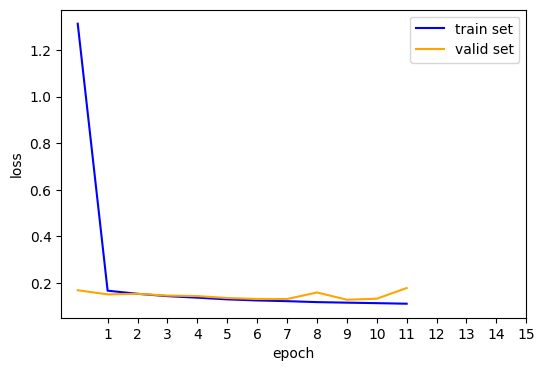

Epoch 11 : Train loss =  0.1108  Valid loss =  0.1781


In [15]:
baseline = BaselineModel(vocab_size)
train_results, valid_results = fit(baseline, train_loader, valid_loader)

## 3. Models with a text feature

### 3.1 Self-taught

In [16]:
# tokenization
def preprocess_text(text, word_to_id, max_len):
    tokens = nltk.word_tokenize(text.lower())

    sequence = [word_to_id.get(token, word_to_id['<UNK>']) for token in tokens]

    if len(sequence) < max_len:
        sequence += [0] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    return sequence

all_tokens = []
for text in x_train.FullDescription:
    all_tokens.extend(nltk.word_tokenize(text.lower()))
word_counts  = Counter(all_tokens)
min_freq = 10
unique_tokens = sorted([word for word,count in word_counts.items() if count >= min_freq])
word_to_id = {word: i+2 for i, word in enumerate(unique_tokens)} # i+2, because 0 is padding and 0 is unknown
word_to_id['<PAD>'] = 0
word_to_id['<UNK>'] = 1
print(len(word_to_id))

33233


In [17]:
# lengths = [len(nltk.word_tokenize(str(text))) for text in x_train.FullDescription]
# np.median(lengths)   # 257

In [18]:
X_text_train = [preprocess_text(t, word_to_id, max_len=300) for t in x_train.FullDescription]
X_text_valid = [preprocess_text(t, word_to_id, max_len=300) for t in x_valid.FullDescription]
X_text_test = [preprocess_text(t, word_to_id, max_len=300) for t in x_test.FullDescription]

In [19]:
class SelfTaughtDataset(Dataset):
    def __init__(self, cat_data, text_data, y):

        self.cat_features = torch.tensor(cat_data.values, dtype=torch.long)
        self.text_feature = torch.tensor(text_data, dtype=torch.long)
        self.y = torch.tensor(y.values.reshape(-1,1), dtype=torch.float32)


    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.cat_features[idx], self.text_feature[idx], self.y[idx]

    
train_dataset = SelfTaughtDataset(x_train[cat_features], X_text_train, y_train)
valid_dataset = SelfTaughtDataset(x_valid[cat_features], X_text_valid, y_valid)
test_dataset = SelfTaughtDataset(x_test[cat_features], X_text_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [20]:
test_dataset[21][1] # example row

tensor([29433, 15784,  2449, 11075, 20989, 29655, 32034, 15211,  2506, 32034,
        31942,     1,   225, 32853, 31834,  3847, 29342, 17944, 22002, 24978,
        12183, 29342, 29292, 31942, 12868,     1, 29655, 14090, 21901, 15580,
        32863, 28996, 15580, 29342, 12611, 32853, 19682, 13702, 13092,  5095,
         8899, 11234,  2980, 31616,  2980, 26857,  3384, 29292, 11234, 29342,
        14673,  5292, 26763, 13702,  1355, 27330,  3546, 14910,  3384, 29292,
          223, 14674, 31952, 11864, 26502, 31942,  1355, 21622, 10320, 20818,
        27292, 23164,  8899,   225, 29407, 26763, 13702,  1074, 32813, 20679,
        11234,   223, 31743, 14953,  3200, 17064,   925, 32813, 31952, 29342,
        27292, 23164, 15072,   225, 29342, 10320, 20679, 29433, 25423, 15784,
        20818, 29342,  3384,  7290, 29292, 20679, 23164, 11685, 14910, 21075,
        29655, 28490,  1355, 19314, 24585,   225, 32778, 15784, 17628, 29804,
         1355, 17976, 32806, 20679, 11189,  2506,  2449, 10839, 

In [21]:
class SelfTaughtModel(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text = 64, emb_dim_cat=16):
        super(SelfTaughtModel, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        input_dim = len(cat_vocab_size) * emb_dim_cat + emb_dim_text

        self.fc1 = nn.Linear(input_dim, 128) 
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64) 
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1) 

    def forward(self, x_cat, x_text):
        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]
        emb_cat = torch.cat(emb_cat, dim=1)
        emb_text = self.text_embeddings(x_text)
        mean_emb_text = torch.mean(emb_text, dim=1)
        emb_combined = torch.cat([emb_cat, mean_emb_text], dim=1)

        x = self.relu1(self.fc1(emb_combined))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)

In [75]:
def fit_text(model, train, valid, loss=nn.MSELoss(), epochs=15, patience=3):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    optimizer = optim.Adam(model.parameters())
    model = model.to(device)

    # metrics
    train_loss = []
    valid_loss = []
    valid_mae = []

    # early stopping parameters
    patience_count = 0
    best_loss = float('inf')
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):

        # training
        train_sum_loss = 0
        model.train()
        
        for batch_x_cat, batch_x_text, batch_y in train:
            batch_x_cat, batch_x_text, batch_y = batch_x_cat.to(device), batch_x_text.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x_cat, batch_x_text)
            l = loss(preds.view(-1), batch_y.view(-1))
            l.backward()
            optimizer.step()

            train_sum_loss += l.item() * batch_x_cat.size(0)
        train_loss.append(train_sum_loss / len(train.dataset))

        # validation
        model.eval()
        valid_sum_loss = 0.0
        valid_sum_mae = 0.0 
        with torch.no_grad():
            for batch_x_cat, batch_x_text, batch_y in valid:
                batch_x_cat, batch_x_text, batch_y = batch_x_cat.to(device), batch_x_text.to(device), batch_y.to(device)
                preds = model(batch_x_cat, batch_x_text)
                l = loss(preds.view(-1), batch_y.view(-1))
                valid_sum_loss += l.item() * batch_x_cat.size(0)

                preds_no_log = torch.expm1(preds.view(-1))
                y_real = torch.expm1(batch_y.view(-1))
                mae = torch.abs(y_real - preds_no_log).mean() * batch_x_cat.size(0)
                valid_sum_mae += mae.item()

        valid_loss.append(valid_sum_loss / len(valid.dataset))
        valid_mae.append(valid_sum_mae / len(valid.dataset))

        # early stopping
        if valid_loss[-1] < best_loss:
            best_loss = valid_loss[-1]
            patience_count = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            patience_count += 1

        if patience_count >= patience:
            break

        # plot
        if epoch > 0:
            display.clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(train_loss, label = "train set", color="blue")
            plt.plot(valid_loss, label="valid set", color="orange")
            plt.legend()
            plt.ylabel("loss")
            plt.xlabel("epoch")
            plt.xticks(range(1,epochs+1))
            plt.show()


        print("Epoch",epoch,": Train loss = " , round(train_loss[-1],4),  " Valid loss = ", round(valid_loss[-1],4))
    model.load_state_dict(best_model)

    return train_loss, valid_loss, valid_mae

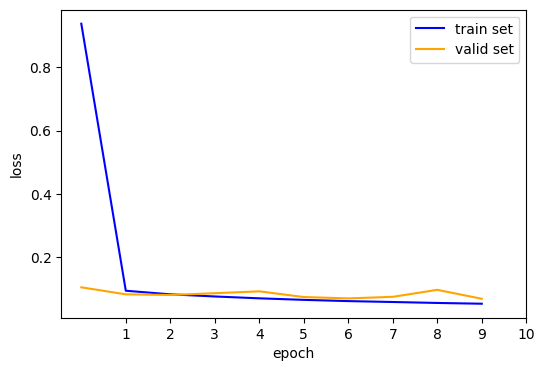

Epoch 9 : Train loss =  0.0535  Valid loss =  0.0691


In [38]:
model_st = SelfTaughtModel(vocab_size, len(word_to_id))
train_lostt, valid_loss, valid_mae = fit_text(model_st, train_loader, valid_loader, epochs=10, patience=3)

In [34]:
valid_loss, valid_mae

([0.10030884864791553,
  0.0934556193259235,
  0.08150915025967069,
  0.09591333333319317],
 [tensor(8279.2266), tensor(7851.4883), tensor(7323.2397), tensor(7968.2432)])

### 3.2 Encode text before model traning with gensim libarary

In [42]:
wtv_model = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
def emb_w2v_google(text_data, w2v_model, dim_emb=300):
    matrix = np.zeros((len(text_data), dim_emb))

    for i, row in enumerate(text_data):
        tokens = nltk.word_tokenize(str(row).lower()) # zamiana opisu na tokeny
        vectors = [w2v_model[word] for word in tokens if word in w2v_model.key_to_index] # tworzymy liste, ktora ma tyle elementow ile slow, a kazdy element to 300 wymiarowy wektor

        if len(vectors) > 0:
            matrix[i] = np.mean(vectors, axis=0) # wyciagamy srednio po kolumnach z embedingu, bedziemy miec wektor 1x300 i wpisujemy go jako ity wiersz naszej macierzy
    return matrix # kazdy wiersz tej macierzy ma 300 kolumn i odpowiada jednemu ogloszenia (srednia z embedingow kazdego slowa)

X_train_w2v = emb_w2v_google(x_train.FullDescription, wtv_model)
X_valid_w2v = emb_w2v_google(x_valid.FullDescription, wtv_model)
X_test_w2v = emb_w2v_google(x_test.FullDescription, wtv_model)

In [71]:
class EncodedDataset(Dataset):
    def __init__(self, cat_data, text_data, y):

        self.cat_data = torch.tensor(cat_data.values, dtype=torch.long)
        self.text_data = torch.tensor(text_data, dtype=torch.float32)
        self.y = torch.tensor(y.values.reshape(-1,1), dtype=torch.float32)
        
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.cat_data[idx], self.text_data[idx], self.y[idx]
    
train_dataset = EncodedDataset(x_train[cat_features], X_train_w2v, y_train)
valid_dataset = EncodedDataset(x_valid[cat_features], X_valid_w2v, y_valid)
test_dataset = EncodedDataset(x_test[cat_features], X_test_w2v, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [72]:
class EncodedModel(nn.Module):
    def __init__(self, cat_vocab, cat_emb_dim=16, text_emb_dim=300):
        super(EncodedModel, self).__init__()

        self.cat_emb = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=cat_emb_dim, padding_idx=0) for size in cat_vocab])

        input_dim = cat_emb_dim * len(cat_vocab) + text_emb_dim

        self.fc1 = nn.Linear(input_dim,128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64) 
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1) 

    def forward(self, x_cat, x_text):

        cat = [layer(x_cat[:,i]) for i, layer in enumerate(self.cat_emb)]
        cat_tensor = torch.cat(cat, dim=1)
        x = torch.cat([cat_tensor, x_text] ,dim =1)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)

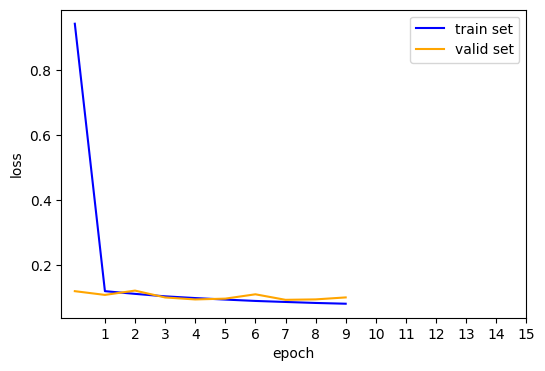

Epoch 9 : Train loss =  0.0825  Valid loss =  0.1018


In [76]:
model_eb = EncodedModel(vocab_size)
train_loss, valid_loss, valid_mae = fit_text(model_eb, train_loader, valid_loader, epochs=15, patience=3)